In [ ]:
import sys

print(sys.executable)

d:\ML lab\Loan-approval_Prediction\venv\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("../dataset/loan_approval_dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
print(df.columns.tolist())

['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


In [7]:
print(df.isnull().sum())

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
print(df.head())

   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0                  1760000

In [10]:
for col in df.columns:
    print(repr(col))

'loan_id'
' no_of_dependents'
' education'
' self_employed'
' income_annum'
' loan_amount'
' loan_term'
' cibil_score'
' residential_assets_value'
' commercial_assets_value'
' luxury_assets_value'
' bank_asset_value'
' loan_status'


In [11]:
df.columns = df.columns.str.strip()

In [12]:
print(df.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [13]:
print(df["loan_status"].value_counts())

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [14]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [15]:
for col in df.columns:
    print("\n", col)
    print(df[col].unique())


 loan_id
[   1    2    3 ... 4267 4268 4269]

 no_of_dependents
[2 0 3 5 4 1]

 education
<StringArray>
[' Graduate', ' Not Graduate']
Length: 2, dtype: str

 self_employed
<StringArray>
[' No', ' Yes']
Length: 2, dtype: str

 income_annum
[9600000 4100000 9100000 8200000 9800000 4800000 8700000 5700000  800000
 1100000 2900000 6700000 5000000 1900000 4700000  500000 2700000 6300000
 5800000 6500000 4900000 3100000 2400000 7000000 9000000 8400000 1700000
 1600000 8000000 3600000 1500000 7800000 1400000 4200000 5500000 9500000
 7300000 3800000 5100000 4300000 9300000 7400000 8500000 8800000 3300000
 3900000 8300000 5600000 5300000 2600000  700000 3500000 9900000 3000000
 6800000 2000000 1000000  300000 6600000 9400000 4400000  400000 6200000
 9700000 7100000  600000 7200000  900000  200000 1800000 4600000 2200000
 2500000 8600000 4000000 5200000 8900000 1300000 4500000 8100000 9200000
 2800000 7500000 6400000 6900000 7700000 3200000 7900000 5900000 3400000
 2100000 3700000 5400000 2300

In [16]:
print(df.dtypes)

loan_id                     int64
no_of_dependents            int64
education                     str
self_employed                 str
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                   str
dtype: object


fixed spaces in the column names

In [17]:
for col in df.select_dtypes(include="str").columns:
    df[col] = df[col].str.strip()

In [18]:
for col in df.select_dtypes(include="str").columns:
    print(col, df[col].unique())

education <StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str
self_employed <StringArray>
['No', 'Yes']
Length: 2, dtype: str
loan_status <StringArray>
['Approved', 'Rejected']
Length: 2, dtype: str


In [19]:
print("Unique loan IDs:", df["loan_id"].nunique())
print("Total rows:", len(df))

Unique loan IDs: 4269
Total rows: 4269


EDA

Loan approval distribution

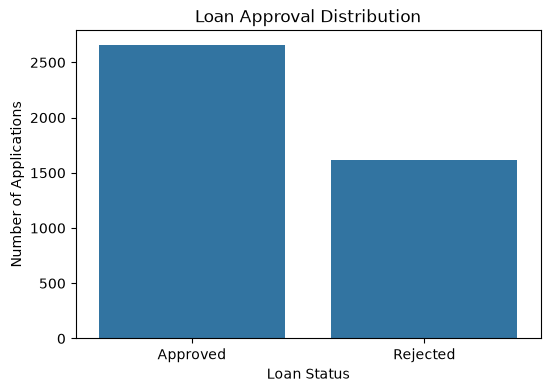

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="loan_status")

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

CIBIL Score vs Loan Status

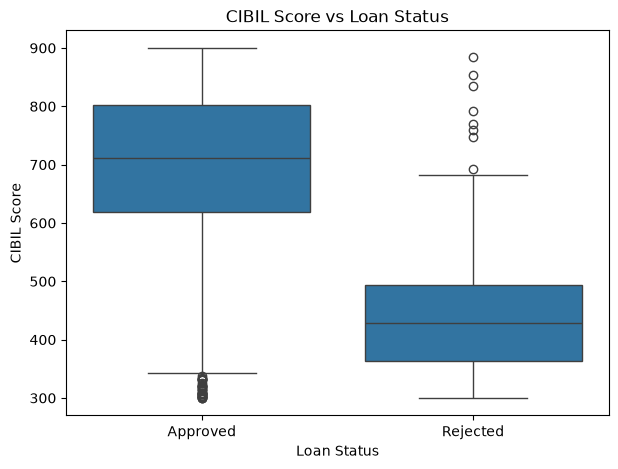

In [21]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="cibil_score"
)

plt.title("CIBIL Score vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("CIBIL Score")

plt.show()

Annual Income vs Loan Status

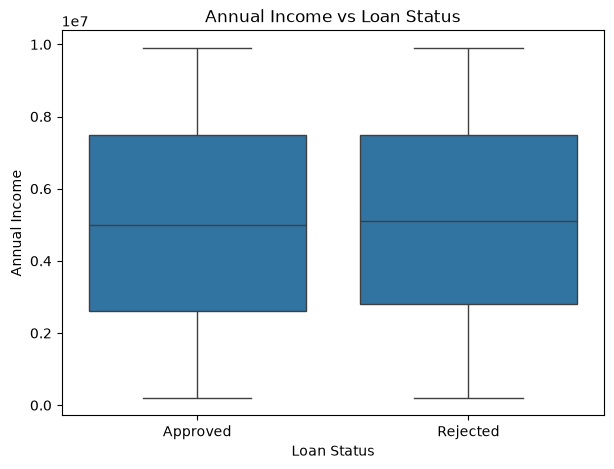

In [22]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="income_annum"
)

plt.title("Annual Income vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")

plt.show()

Loan Amount vs Loan Status

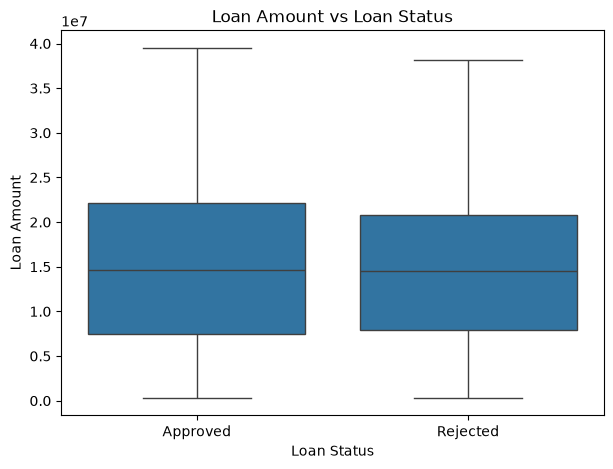

In [23]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="loan_amount"
)

plt.title("Loan Amount vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")

plt.show()

Education vs Loan Status

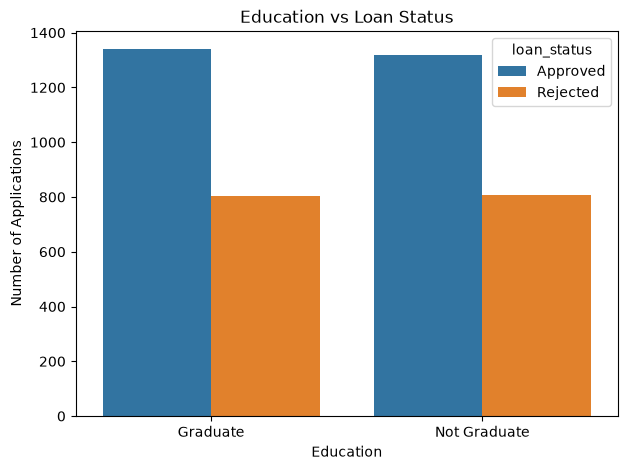

In [24]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="education",
    hue="loan_status"
)

plt.title("Education vs Loan Status")
plt.xlabel("Education")
plt.ylabel("Number of Applications")

plt.show()

Self Employment vs Loan Status

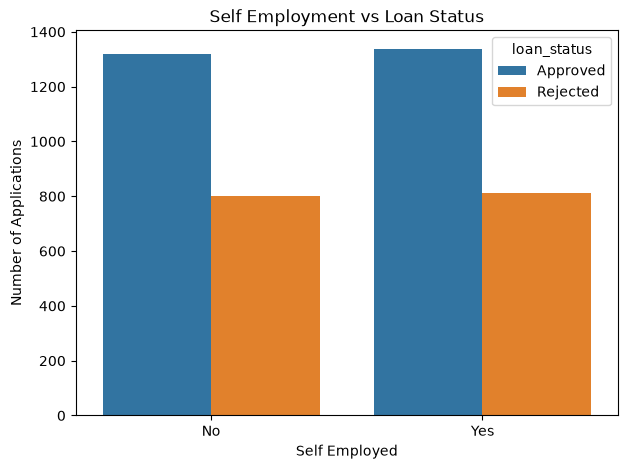

In [25]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="self_employed",
    hue="loan_status"
)

plt.title("Self Employment vs Loan Status")
plt.xlabel("Self Employed")
plt.ylabel("Number of Applications")

plt.show()

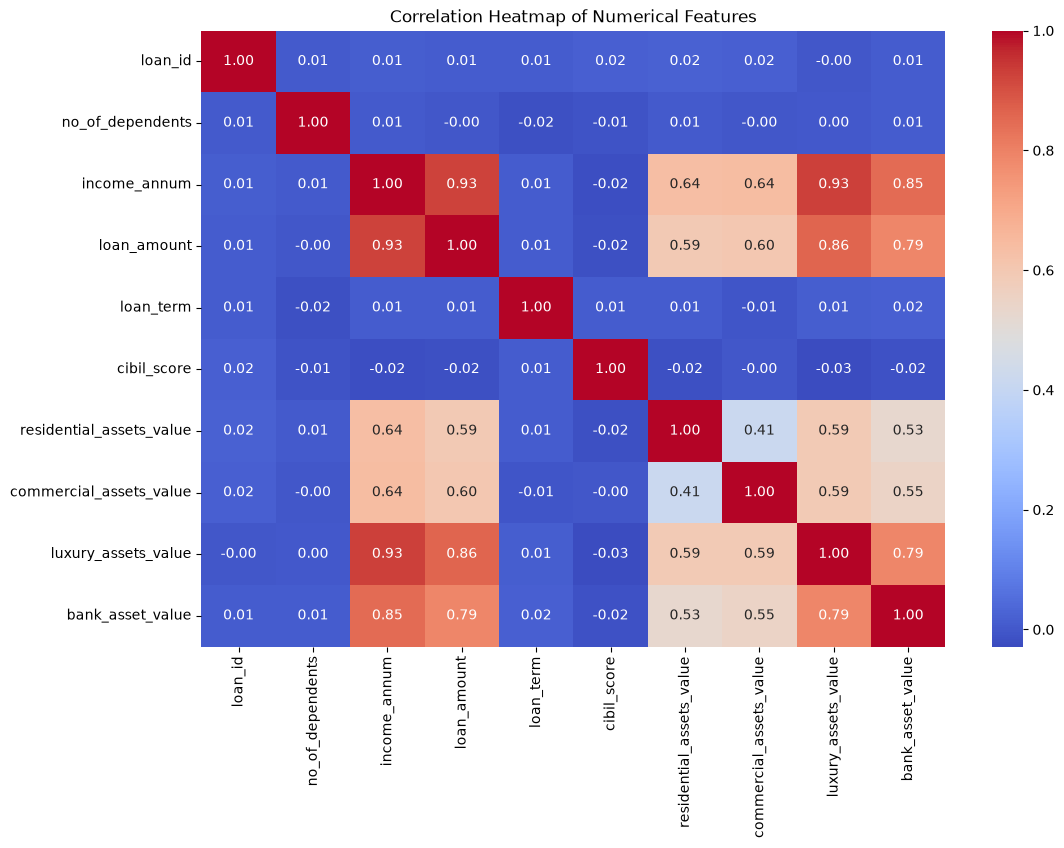

In [26]:
plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

Data Preprocessing.

In [27]:
# Remove loan_id because it is only an identifier
df = df.drop("loan_id", axis=1)

df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [28]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4269, 11)
Target shape: (4269,)


In [29]:
y = y.map({
    "Rejected": 0,
    "Approved": 1
})

print(y.value_counts())

loan_status
1    2656
0    1613
Name: count, dtype: int64


In [30]:
categorical_features = ["education", "self_employed"]

numerical_features = [
    "no_of_dependents",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['education', 'self_employed']

Numerical features:
['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [31]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print(y.value_counts())

Features shape: (4269, 11)
Target shape: (4269,)
loan_status
1    2656
0    1613
Name: count, dtype: int64


Train/Test Split + Preprocessing Pipeline.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3415, 11)
Testing data: (854, 11)


In [34]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [35]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3415, 11)
Testing data: (854, 11)


Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [37]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42, max_iter=1000))
    ]
)

In [38]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [39]:
y_pred_lr = logistic_model.predict(X_test)

print(y_pred_lr[:20])

[1 0 1 1 1 1 1 0 1 0 0 0 1 0 1 0 1 1 1 0]
